# This notebook




Is divided up like this:

---

Task X

Python code for solving the task

Findings/suggestion to what we should write in overleaf

---

## Task one - Exploration of data

Data Exploration (10)

> a. Explore the dataset by displaying the first few rows, summary statistics, and data
types of each column.

> b. Identify missing values, outliers, and unique values in categorical columns.

In [19]:
# importing stuff and defining the csv https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
import pandas as pd
import matplotlib.pyplot as plt # For plotting
from scipy.stats import zscore # For calculating z-scores, evt andre ting vi trenger
import numpy as np


datafile= r"../data/smoking_driking_dataset_Ver01.csv"
df = pd.read_csv(datafile)

In [20]:
print("Example sample of how the data looks like")
df.head()

Example sample of how the data looks like


,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N


In [21]:
# Table with overall information on the data

print("===== OVERALL INFO =====") # https://www.w3schools.com/python/pandas/ref_df_info.asp

print(f"Observations: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

if df.isnull().sum().sum() == 0:
    print("No missing values in the dataset.\n")
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

print("Table with columns")
info_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values, # Datatype
    "Missing": df.isnull().sum().values, # See if any missing values
    "Unique Values": df.nunique().values # Number of unique values, those with low are liekly categorical values like, male/female, yes/no https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html
})

display(info_table)

===== OVERALL INFO =====
Observations: 991,346
Variables: 24
No missing values in the dataset.

Table with columns


,Column,Data Type,Missing,Unique Values
0,sex,str,0,2
1,age,int64,0,14
2,height,int64,0,13
3,weight,int64,0,24
4,waistline,float64,0,737
5,sight_left,float64,0,24
6,sight_right,float64,0,24
7,hear_left,float64,0,2
8,hear_right,float64,0,2
9,SBP,float64,0,171


In [22]:
# Statistics per column
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,991346.0,47.614491,14.181339,20.0,35.0,45.0,60.0,85.0
height,991346.0,162.240625,9.282957,130.0,155.0,160.0,170.0,190.0
weight,991346.0,63.284050,12.514241,25.0,55.0,60.0,70.0,140.0
waistline,991346.0,81.233358,11.850323,8.0,74.1,81.0,87.8,999.0
sight_left,991346.0,0.980834,0.605949,0.1,0.7,1.0,1.2,9.9
sight_right,991346.0,0.978429,0.604774,0.1,0.7,1.0,1.2,9.9
hear_left,991346.0,1.031495,0.174650,1.0,1.0,1.0,1.0,2.0
hear_right,991346.0,1.030476,0.171892,1.0,1.0,1.0,1.0,2.0
SBP,991346.0,122.432498,14.543148,67.0,112.0,120.0,131.0,273.0
DBP,991346.0,76.052627,9.889365,32.0,70.0,76.0,82.0,185.0


In [23]:
# Tolker dem slikt: DRK_YN: Do you drink, yes/no? 
# SMK_stat_...:
# Do you smoke? 1: Never smoked, 2 I used to smoke but have now stopped, 3: I currently smoke

# Data on main categories

print("Sex")
print(f"Male: {df['sex'].value_counts()['Male']:,}")
print(f"Female: {df['sex'].value_counts()['Female']:,}")

print("\nAlcohol")
print(f"Drinks: {df['DRK_YN'].value_counts()['Y']:,}")
print(f"Does not drink: {df['DRK_YN'].value_counts()['N']:,}")

smoking = df["SMK_stat_type_cd"].value_counts()

print("\nSmoking")
print(f"Never smoked: {smoking[1.0]:,}")
print(f"Former smoker: {smoking[2.0]:,}")
print(f"Current smoker: {smoking[3.0]:,}")

Sex
Male: 526,415
Female: 464,931

Alcohol
Drinks: 495,488
Does not drink: 495,858

Smoking
Never smoked: 602,441
Former smoker: 174,951
Current smoker: 213,954


In [24]:
# Summary statistics

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].describe().T[
    ["min", "25%", "50%", "75%", "max"]
]

,min,25%,50%,75%,max
age,20.0,35.0,45.0,60.0,85.0
height,130.0,155.0,160.0,170.0,190.0
weight,25.0,55.0,60.0,70.0,140.0
waistline,8.0,74.1,81.0,87.8,999.0
sight_left,0.1,0.7,1.0,1.2,9.9
sight_right,0.1,0.7,1.0,1.2,9.9
hear_left,1.0,1.0,1.0,1.0,2.0
hear_right,1.0,1.0,1.0,1.0,2.0
SBP,67.0,112.0,120.0,131.0,273.0
DBP,32.0,70.0,76.0,82.0,185.0


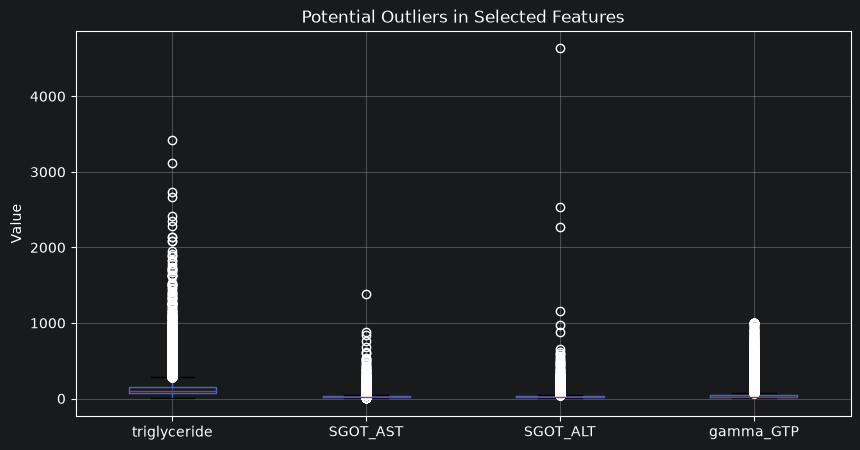

In [25]:
sample = df.sample(100000, random_state=42)

sample[
    ["triglyceride", "SGOT_AST", "SGOT_ALT", "gamma_GTP"]
].boxplot(figsize=(10, 5))

plt.title("Potential Outliers in Selected Features")
plt.ylabel("Value")
plt.show()

### Suggested writings task 1:


2 Data Exploration
The dataset contains 991,346 observations and 24 variables. Most variables
are numerical health measurements, including age, blood pressure, cholesterol,
triglycerides, blood glucose, and liver enzyme measurements. The dataset also
contains categorical variables describing sex, alcohol consumption, and smoking
status.

2.1 Dataset Structure
The dataset contains 19 variables stored as float64, 3 as int64, and 2 as
strings. Although SMK stat type cd is stored numerically, it represents three
smoking categories rather than a continuous measurement.
The main categorical variables are summarized below:
No missing values were found in any of the 24 variables.

2.2 Summary Statistics and Potential Outliers
The summary statistics indicate that several variables contain values far above
their typical ranges. For example, the 75th percentile of triglyceride is 159,
while the maximum value is 9,490. Similarly, SGOT AST has a 75th percentile of
28 and a maximum of 9,999, while SGOT ALT has a 75th percentile of 29 and a
maximum of 7,210.

- Table of the categories sex, alcohol yes/no, smoking never/former/current

- Then the graph with potential outliers

- brief explanation

## Task 2 Data Cleaning

Data Cleaning (20)
> a. Handling Missing Values

> b. Choose appropriate methods to handle missing values (e.g., mean/median imputation for numerical data, mode imputation for categorical data, or deletion of rows/columns).

> c. Justify your choices for handling missing data.

The primary dataset is checked below. A separate energy dataset is then used to demonstrate missing-value handling.


In [26]:

# FOR THE DATASET SMOKING/DRINKING

# Missing values
print(f"Missing values: {df.isnull().sum().sum()}")

# Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

df = df.drop_duplicates()

print(f"Rows after cleaning: {len(df):,}")

Missing values: 0
Duplicate rows: 26
Rows after cleaning: 991,320


### Missing values in a second dataset

The smoking/drinking dataset has no missing values detected by `isna()`, so it does not need imputation. For this part, we use `energy_dataset.csv` from the course-provided `spanish-cities-energy-consumption.zip`. It contains hourly energy generation, load and price records for 2015–2018. Only this CSV is needed; the accompanying weather file is not used.

Place the CSV in `data/` and run the notebook with `src/` as the working directory. The following energy cells can also be run independently. All energy data is kept in separate variables; it is not merged with the smoking/drinking data or used in its later preprocessing.

In [27]:
from pathlib import Path
import pandas as pd
from IPython.display import display

energy_path = Path("../data/energy_dataset.csv")
if not energy_path.is_file():
    raise FileNotFoundError(
        "Extract energy_dataset.csv into data/ and run this notebook from src/."
    )

energy_raw = pd.read_csv(energy_path)
# Normalize the varying UTC offsets before checking elapsed hourly intervals.
energy_data = energy_raw.assign(
    time=pd.to_datetime(energy_raw["time"], utc=True)
).set_index("time")

assert energy_data.index.notna().all(), "Missing timestamps need investigation."
assert energy_data.index.is_unique, "Duplicate timestamps need investigation."
assert energy_data.index.is_monotonic_increasing, "Rows must be chronological."
assert energy_data.index.to_series().diff().dropna().eq(pd.Timedelta(hours=1)).all()

print(f"Original shape: {energy_raw.shape[0]:,} rows, {energy_raw.shape[1]} columns (including time)")
print("Timestamps are unique, ordered and exactly one hour apart in UTC.")

Original shape: 35,064 rows, 29 columns (including time)
Timestamps are unique, ordered and exactly one hour apart in UTC.


In [28]:
def energy_longest_missing_run(series):
    # Each observed value starts a new group, followed by any missing hours.
    return int(series.isna().groupby(series.notna().cumsum()).sum().max())


energy_missing_counts = energy_data.isna().sum()
energy_gap_lengths = energy_data.apply(energy_longest_missing_run)
energy_missing_summary = pd.DataFrame({
    "Missing values": energy_missing_counts,
    "Missing (%)": (100 * energy_missing_counts / len(energy_data)).round(3),
    "Longest gap (hours)": energy_gap_lengths,
})
display(energy_missing_summary.loc[energy_missing_counts > 0])

energy_empty_columns = energy_data.columns[energy_data.isna().all()].tolist()
energy_retained = energy_data.drop(columns=energy_empty_columns)
energy_missing_mask = energy_retained.isna()
energy_affected_rows = int(energy_missing_mask.any(axis=1).sum())

print("Entirely empty columns:", energy_empty_columns)
print(f"Remaining missing cells: {int(energy_missing_mask.sum().sum()):,}")
print(f"Affected rows after removing empty columns: {energy_affected_rows:,} ({100 * energy_affected_rows / len(energy_retained):.3f}%)")
print(f"Longest remaining gap: {energy_gap_lengths.loc[energy_retained.columns].max()} hours")
print("Missing values at the first/last timestamp:", int(energy_retained.iloc[[0, -1]].isna().sum().sum()))

,Missing values,Missing (%),Longest gap (hours)
generation biomass,19,0.054,6
generation fossil brown coal/lignite,18,0.051,6
generation fossil coal-derived gas,18,0.051,6
generation fossil gas,18,0.051,6
generation fossil hard coal,18,0.051,6
generation fossil oil,19,0.054,6
generation fossil oil shale,18,0.051,6
generation fossil peat,18,0.051,6
generation geothermal,18,0.051,6
generation hydro pumped storage aggregated,35064,100.000,35064


Entirely empty columns: ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']
Remaining missing cells: 401
Affected rows after removing empty columns: 47 (0.134%)
Longest remaining gap: 8 hours
Missing values at the first/last timestamp: 0


### Choice of treatment

`generation hydro pumped storage aggregated` and `forecast wind offshore eday ahead` are entirely empty. We remove these columns because they contain no observations from which to estimate replacements. Filling them with zero would confuse unknown values with recorded zero generation.

The retained columns contain 401 missing cells across 47 rows (0.134% of all rows). Gaps are at most eight consecutive hours, with observed values on both sides. We use linear interpolation based on elapsed time for these interior gaps. This preserves the regular hourly series and uses the local values surrounding each gap. Dropping the 47 rows would break that continuity; a global mean or median would ignore local variation, while forward filling would assume a constant value throughout each gap.

Eight hours is a limit chosen to cover the observed gaps, not a universally safe threshold. We check the gap lengths before interpolation, since pandas' `limit` alone can partially fill a longer gap. Observed zeros are retained.

This is retrospective cleaning: interpolation uses both earlier and later observations and may smooth real peaks or rapid changes. We cannot verify the missing values' true values. This method must be reconsidered for forecasting, where future observations and information across a train/test boundary must not be used.

In [29]:
energy_gap_limit = 8
assert energy_gap_lengths.loc[energy_retained.columns].le(energy_gap_limit).all(), "Review gaps longer than eight hours."
assert not energy_retained.iloc[[0, -1]].isna().any().any(), "Boundary gaps need a separate method."

energy_clean = energy_retained.interpolate(
    method="time",
    limit=energy_gap_limit,
    limit_direction="forward",
    limit_area="inside",
)

# Verify that only previously missing values in retained columns were changed.
pd.testing.assert_frame_equal(
    energy_clean.where(~energy_missing_mask), energy_retained
)
assert energy_clean.index.equals(energy_data.index)
assert energy_clean.columns.equals(energy_retained.columns)
assert not energy_clean.isna().any().any()

print(f"Filled {int(energy_missing_mask.sum().sum()):,} missing cells.")
print("All rows, timestamps and observed values in retained columns are preserved.")
print("Remaining missing values:", int(energy_clean.isna().sum().sum()))

Filled 401 missing cells.
All rows, timestamps and observed values in retained columns are preserved.
Remaining missing values: 0


In [30]:
energy_before_after = pd.DataFrame({
    "Original": [
        len(energy_raw), energy_raw.shape[1],
        int(energy_raw.isna().sum().sum()),
        int(energy_raw.isna().any(axis=1).sum()),
    ],
    "After dropping empty columns": [
        len(energy_retained), energy_retained.shape[1] + 1,
        int(energy_missing_mask.sum().sum()), energy_affected_rows,
    ],
    "After interpolation": [
        len(energy_clean), energy_clean.shape[1] + 1,
        int(energy_clean.isna().sum().sum()),
        int(energy_clean.isna().any(axis=1).sum()),
    ],
}, index=["Rows", "Columns (including time)", "Missing cells", "Rows with missing values"])
display(energy_before_after)

# Inspect a few actual replacements; these are estimates, not recovered truths.
energy_example_times = energy_retained.index[energy_missing_mask["total load actual"]][:5]
display(pd.DataFrame({
    "Original total load actual": energy_retained.loc[energy_example_times, "total load actual"],
    "Interpolated total load actual": energy_clean.loc[energy_example_times, "total load actual"],
}).round(2))

,Original,After dropping empty columns,After interpolation
Rows,35064,35064,35064
Columns (including time),29,27,27
Missing cells,70529,401,0
Rows with missing values,35064,47,0


,Original total load actual,Interpolated total load actual
time,,
2015-01-05 11:00:00+00:00,NaN,24066.0
2015-01-05 12:00:00+00:00,NaN,23703.0
2015-01-05 13:00:00+00:00,NaN,23340.0
2015-01-05 14:00:00+00:00,NaN,22977.0
2015-01-05 15:00:00+00:00,NaN,22614.0


### Findings for the report

The secondary dataset contains 35,064 hourly records and 29 columns, including the timestamp. Removing two wholly empty columns reduces the missing-cell count from 70,529 to 401. These remaining gaps affect 47 rows and span at most eight consecutive hours. Time-based linear interpolation fills all 401 cells, leaving 35,064 records and 27 columns (including the timestamp), with no missing values. No rows or observed values in retained columns are changed. The before/after table distinguishes column removal from imputation; the large initial missing count mostly comes from the two empty columns.

This demonstrates column deletion and numerical imputation with different justifications. It does not establish that the estimates are exact or that interpolation is best for every forecasting use case. The main smoking/drinking dataframe remains separate, with its original duplicate-removal step preserved above.

API references: [pandas time interpolation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html) and [UTC timestamp conversion](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html).

## Task 3 outliers something


Handling Outliers (20)

> a. Detect outliers using methods such as the IQR method or Z-score.

> b. Decide whether to remove, cap, or transform the outliers. Justify your decisions.


comparing iqr to z score

"The Interquartile Range (IQR) is a measure of statistical dispersion that describes the spread of the middle 50% of a dataset." https://www.geeksforgeeks.org/dsa/interquartile-range-iqr/

In [31]:
# Outlier detection using IQR and Z-score methods for all columns in the dataset.

columns = [
    "age",
    "height",
    "weight",
    "waistline",
    "sight_left",
    "sight_right",
    "SBP",
    "DBP",
    "BLDS",
    "tot_chole",
    "HDL_chole",
    "LDL_chole",
    "triglyceride",
    "hemoglobin",
    "serum_creatinine",
    "SGOT_AST",
    "SGOT_ALT",
    "gamma_GTP"
]

results = []

for col in columns:

    # IQR method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    iqr_count = ((df[col] < lower) | (df[col] > upper)).sum()

    # Z-score method
    z = np.abs(zscore(df[col]))
    z_count = (z > 3).sum()

    results.append({
        "Column": col,
        "IQR Outliers": iqr_count,
        "IQR %": iqr_count / len(df) * 100,
        "Z-score Outliers": z_count,
        "Z-score %": z_count / len(df) * 100
    })

outlier_comparison = pd.DataFrame(results)

outlier_comparison = outlier_comparison.sort_values(
    "IQR %",
    ascending=False
)

display(
    outlier_comparison.style.format({
        "IQR %": "{:.2f}%",
        "Z-score %": "{:.2f}%"
    })
)


,Column,IQR Outliers,IQR %,Z-score Outliers,Z-score %
17,gamma_GTP,94141,9.50%,15360,1.55%
16,SGOT_ALT,72928,7.36%,10370,1.05%
15,SGOT_AST,67614,6.82%,5887,0.59%
8,BLDS,64198,6.48%,18619,1.88%
12,triglyceride,54098,5.46%,14627,1.48%
2,weight,19217,1.94%,4579,0.46%
6,SBP,15835,1.60%,6422,0.65%
10,HDL_chole,13858,1.40%,3877,0.39%
7,DBP,13121,1.32%,6204,0.63%
4,sight_left,11581,1.17%,3118,0.31%


In [32]:
# Top 5 "worst" as in highest detected outlier percentage

outlier_comparison["Worst %"] = outlier_comparison[
    ["IQR %", "Z-score %"]
].max(axis=1)

worst = outlier_comparison.sort_values(
    "Worst %",
    ascending=False
)

display(
    worst.head(5).style.format({
        "IQR %": "{:.2f}%",
        "Z-score %": "{:.2f}%",
        "Worst %": "{:.2f}%"
    })
)

,Column,IQR Outliers,IQR %,Z-score Outliers,Z-score %,Worst %
17,gamma_GTP,94141,9.50%,15360,1.55%,9.50%
16,SGOT_ALT,72928,7.36%,10370,1.05%,7.36%
15,SGOT_AST,67614,6.82%,5887,0.59%,6.82%
8,BLDS,64198,6.48%,18619,1.88%,6.48%
12,triglyceride,54098,5.46%,14627,1.48%,5.46%


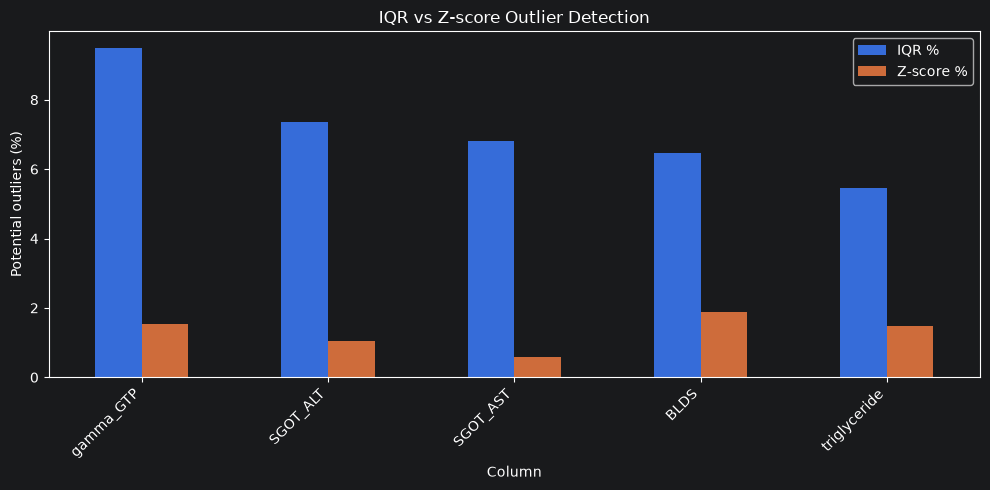

In [33]:
worst_features = worst.head(5)["Column"]

comparison_plot = (
    outlier_comparison
    .set_index("Column")
    .loc[worst_features, ["IQR %", "Z-score %"]]
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Potential outliers (%)")
plt.title("IQR vs Z-score Outlier Detection")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
worst_features = worst.head(5)["Column"].tolist()

display(
    df[worst_features]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
gamma_GTP,991320.0,37.136152,50.423811,1.0,8.0,16.0,23.0,39.0,105.0,232.0,999.0
SGOT_ALT,991320.0,25.755148,26.308910,1.0,7.0,15.0,20.0,29.0,59.0,106.0,7210.0
SGOT_AST,991320.0,25.989424,23.493668,1.0,12.0,19.0,23.0,28.0,46.0,79.0,9999.0
BLDS,991320.0,100.424305,24.179852,25.0,71.0,88.0,96.0,105.0,137.0,204.0,852.0
triglyceride,991320.0,132.140030,102.194762,1.0,34.0,73.0,106.0,159.0,297.0,499.0,9490.0


In [35]:
skewness = df[worst_features].skew().sort_values(
    ascending=False
)

display(skewness)

SGOT_AST        150.490203
SGOT_ALT         50.038404
gamma_GTP         7.718657
triglyceride      6.529776
BLDS              4.617495
dtype: float64

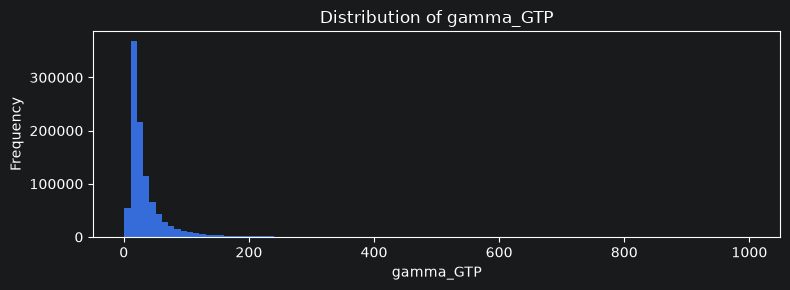

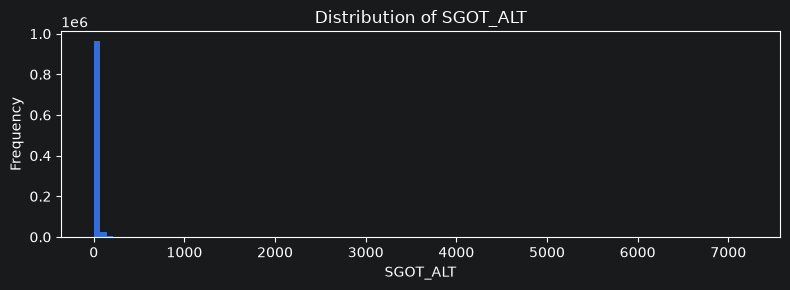

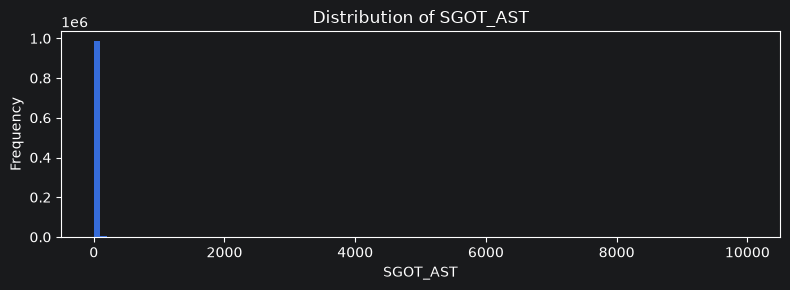

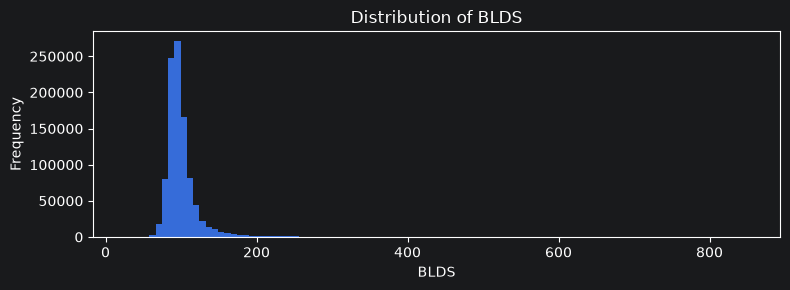

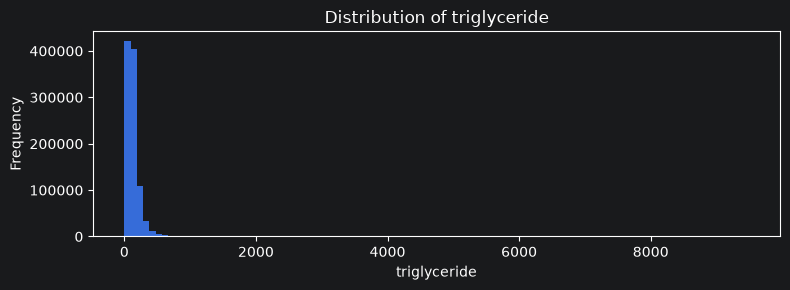

In [36]:
for col in worst_features:
    plt.figure(figsize=(8, 3))

    plt.hist(df[col], bins=100)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

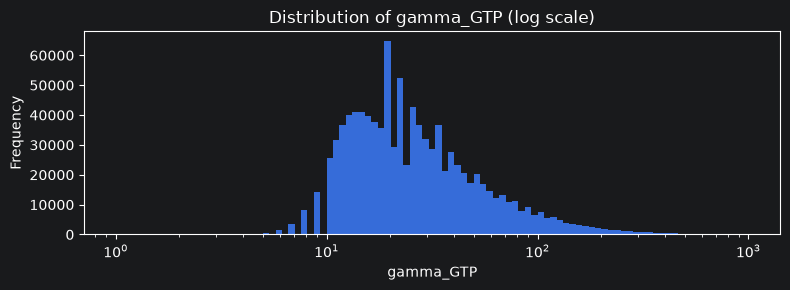

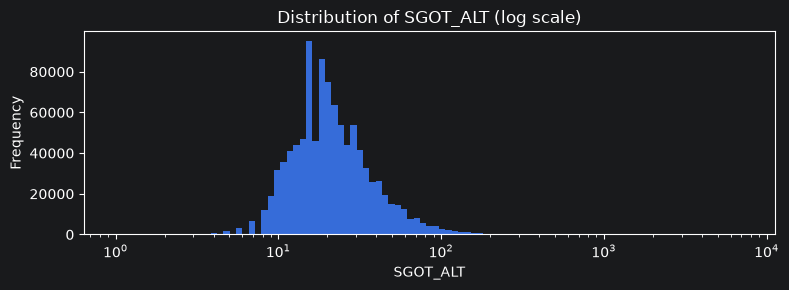

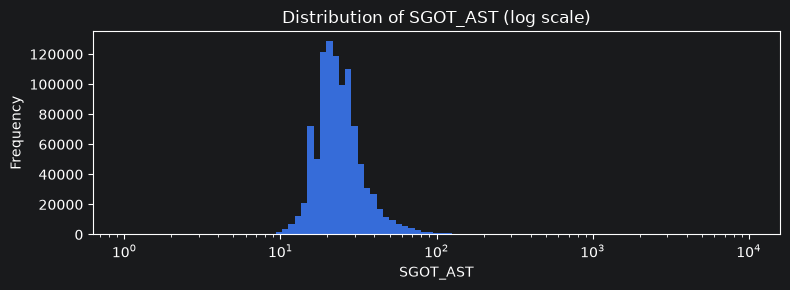

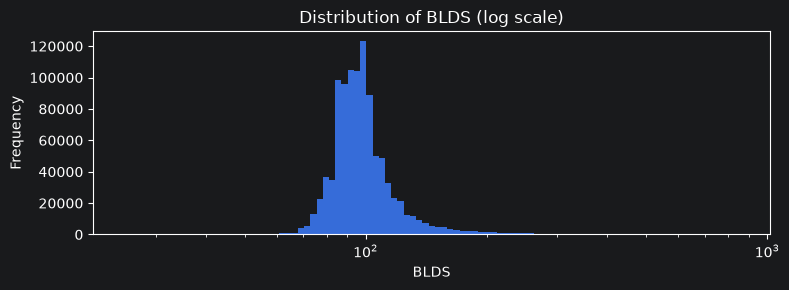

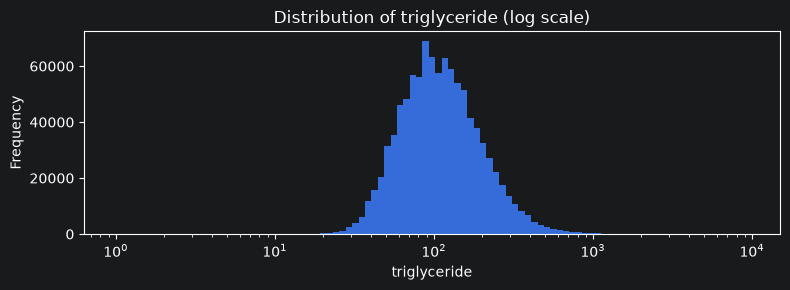

In [37]:
# The last ones just logarithmically scaled

for col in worst_features:
    values = df[col][df[col] > 0]

    bins = np.logspace(
        np.log10(values.min()),
        np.log10(values.max()),
        100
    )

    plt.figure(figsize=(8, 3))
    plt.hist(values, bins=bins)

    plt.xscale("log")
    plt.title(f"Distribution of {col} (log scale)")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [38]:
log_columns = [
    "gamma_GTP",
    "SGOT_ALT",
    "SGOT_AST",
    "BLDS",
    "triglyceride"
]

# Skewness before transformation
skew_before = df[log_columns].skew()

# Create a copy so the original dataframe is not changed
df_log = df.copy()

# Apply logarithmic transformation
for col in log_columns:
    df_log[col] = np.log1p(df_log[col])

# Skewness after transformation
skew_after = df_log[log_columns].skew()

# Compare results
skewness_comparison = pd.DataFrame({
    "Before log transformation": skew_before,
    "After log transformation": skew_after
})

display(skewness_comparison)

,Before log transformation,After log transformation
gamma_GTP,7.718657,1.021365
SGOT_ALT,50.038404,0.775826
SGOT_AST,150.490203,1.427051
BLDS,4.617495,2.033597
triglyceride,6.529776,0.420522


In [39]:
from scipy.stats import boxcox

blds_boxcox, fitted_lambda = boxcox(df["BLDS"])

print("Original:", df["BLDS"].skew())
print("Log1p:", np.log1p(df["BLDS"]).skew())
print("Box-Cox:", pd.Series(blds_boxcox).skew())
print("Lambda:", fitted_lambda)

Original: 4.617495260978581
Log1p: 2.0335967181879298
Box-Cox: -0.24482839575638007
Lambda: -1.8043454919997968



### Explanation of results

For outlier detection I used both IQR and Z-score 

Short explanation of results


A)

* Most affected features: `gamma_GTP`, `SGOT_ALT`, `SGOT_AST`, `BLDS`, `triglyceride`.
They were chosen as they had outlier rates between 5-9%, compared to next which was weight at <2%

* IQR vs Z-score: IQR detected more potential outliers, especially in right-skewed variables.
* Interpretation: Statistical outliers are not automatically incorrect values.
* Skewness: All five selected features were strongly right-skewed. (which means most are in a cluster of small values, but there are some larger values which stretch the distribution to the right. compare 99% with max and youll see)


B)

This is medical data as well as we dont have domain knowledge or any knowledge on how the data was taken, so it would be wrong to just cap or remove as we dont have any evidence there were any errors. 
* No removal/capping: Extreme observations were retained because there was no evidence that they were data errors.

Therefore I chose to log transform them, because it is more aggressive for higher values compared to lower ones.
e.g.:

23 -> log1p = 3.18

79 -> log1p = 4.38

9999 -> log1p = 9.21

* Treatment: `gamma_GTP`, `SGOT_ALT`, `SGOT_AST`, and `triglyceride` were log-transformed with `log1p`.

When it came to BLDS, 
For BLDS, log transformation reduced skewness from 4.62 to 2.03, but the distribution still remained skewed.
I tried box-cox and it went from 4.62 to -0.24 which makes it much better


Below there are some graphs used for the report


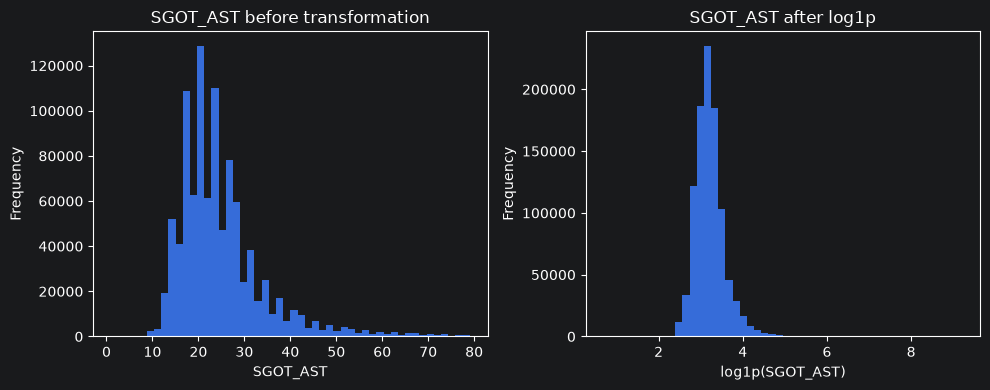

In [40]:
# These are for the report:

limit = df["SGOT_AST"].quantile(0.99)

# Only for plotting
sgot_plot = df.loc[df["SGOT_AST"] <= limit, "SGOT_AST"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Original distribution, first 99%
axes[0].hist(sgot_plot, bins=50)
axes[0].set_title("SGOT_AST before transformation")
axes[0].set_xlabel("SGOT_AST")
axes[0].set_ylabel("Frequency")

# Log-transformed full dataset
axes[1].hist(np.log1p(df["SGOT_AST"]), bins=50)
axes[1].set_title("SGOT_AST after log1p")
axes[1].set_xlabel("log1p(SGOT_AST)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

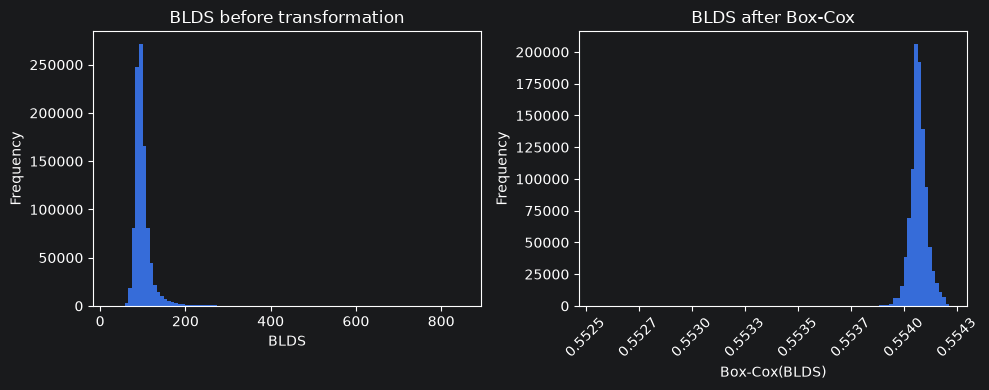

In [41]:
# These are for the report:

from scipy.stats import boxcox
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

blds_boxcox, fitted_lambda = boxcox(df["BLDS"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df["BLDS"], bins=100)
axes[0].set_title("BLDS before transformation")
axes[0].set_xlabel("BLDS")
axes[0].set_ylabel("Frequency")

axes[1].hist(blds_boxcox, bins=100)
axes[1].set_title("BLDS after Box-Cox")
axes[1].set_xlabel("Box-Cox(BLDS)")
axes[1].set_ylabel("Frequency")

# Rotate the x-axis labels by 45 degrees to prevent overlap
axes[1].tick_params(axis='x', rotation=45)

# Limit the decimal precision to a specific number of places (e.g., 4)
axes[1].xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()

In [42]:
# Applying the transformations to the dataset:

import numpy as np
from scipy.stats import boxcox

log_columns = [
    "gamma_GTP",
    "SGOT_ALT",
    "SGOT_AST",
    "triglyceride"
]

# Apply log transformation directly to df
for col in log_columns:
    df[col] = np.log1p(df[col])

# Apply Box–Cox transformation directly to BLDS
df["BLDS"], bl_ds_lambda = boxcox(df["BLDS"])

print(f"Applied log transformation to columns: {log_columns} and Box-Cox transformation to 'BLDS' with lambda: {bl_ds_lambda:.4f}")

Applied log transformation to columns: ['gamma_GTP', 'SGOT_ALT', 'SGOT_AST', 'triglyceride'] and Box-Cox transformation to 'BLDS' with lambda: -1.8043


## Task 4 - Data Transformation

Data Transformation (30)

> a. Encoding Categorical Data

> i. Apply label encoding or one-hot encoding to transform categorical data into numerical form.

> ii. Justify your choice of encoding method.

> b. Feature Scaling

> i. Apply feature scaling techniques such as normalization (Min-Max scaling) or standardization (Z-score normalization) to the dataset.

> ii. Explain why feature scaling is necessary and how it impacts the model.## Task 4 goes here

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# These columns contain categories even though some of them are stored as numbers.
categorical_columns = [
    "sex",
    "DRK_YN",
    "hear_left",
    "hear_right",
    "SMK_stat_type_cd",
    "urine_protein"
]

# All remaining columns are continuous numerical variables.
numeric_columns = [
    col for col in df.columns
    if col not in categorical_columns
]

print("Categorical variables:")
print(categorical_columns)

print("\nNumerical variables:")
print(numeric_columns)

print(f"\nCategorical variables: {len(categorical_columns)}")
print(f"Numerical variables: {len(numeric_columns)}")

Categorical variables:
['sex', 'DRK_YN', 'hear_left', 'hear_right', 'SMK_stat_type_cd', 'urine_protein']

Numerical variables:
['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']

Categorical variables: 6
Numerical variables: 18


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# These columns contain categories even though some of them are stored as numbers.
categorical_columns = [
    "sex",
    "DRK_YN",
    "hear_left",
    "hear_right",
    "SMK_stat_type_cd",
    "urine_protein"
]

# All remaining columns are continuous numerical variables.
numeric_columns = [
    col for col in df.columns
    if col not in categorical_columns
]

print("Categorical variables:")
print(categorical_columns)

print("\nNumerical variables:")
print(numeric_columns)

print(f"\nCategorical variables: {len(categorical_columns)}")
print(f"Numerical variables: {len(numeric_columns)}")

Categorical variables:
['sex', 'DRK_YN', 'hear_left', 'hear_right', 'SMK_stat_type_cd', 'urine_protein']

Numerical variables:
['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']

Categorical variables: 6
Numerical variables: 18


In [45]:
# One-hot encode categorical variables.
#
# drop="if_binary":
# Binary variables only need one output column instead of two.
#
# Examples:
# sex -> sex_Male
# DRK_YN -> DRK_YN_Y
#
# Variables with more than two categories keep one column per category.

encoder = OneHotEncoder(
    drop="if_binary",
    handle_unknown="ignore",
    sparse_output=False
)

scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, numeric_columns),
        ("cat", encoder, categorical_columns)
    ],
    verbose_feature_names_out=False
)

transformed_data = preprocessor.fit_transform(df)

feature_names = preprocessor.get_feature_names_out()

df_transformed = pd.DataFrame(
    transformed_data,
    columns=feature_names,
    index=df.index
)

print("Original dataset shape:", df.shape)
print("Transformed dataset shape:", df_transformed.shape)

display(df_transformed.head())

Original dataset shape: (991320, 24)
Transformed dataset shape: (991320, 31)


,age,height,weight,waistline,sight_left,sight_right,SBP,DBP,BLDS,tot_chole,...,hear_right_2.0,SMK_stat_type_cd_1.0,SMK_stat_type_cd_2.0,SMK_stat_type_cd_3.0,urine_protein_1.0,urine_protein_2.0,urine_protein_3.0,urine_protein_4.0,urine_protein_5.0,urine_protein_6.0
0,-0.889516,0.835883,0.936234,0.739792,0.031630,0.035669,-0.167252,0.399163,0.202839,-0.066135,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-1.242092,1.913131,1.335783,0.655406,-0.133399,0.366369,0.520360,0.601401,0.599916,0.839192,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.536940,0.297260,0.936234,0.824178,0.361689,0.862418,-0.167252,-0.612028,0.139543,-1.540524,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.168212,1.374507,1.335783,0.824178,0.856776,0.366369,1.551779,1.106996,-0.061667,0.140797,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.168212,0.297260,-0.262415,-0.104070,0.031630,0.366369,1.070450,0.601401,0.324193,0.089064,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [46]:
# Show the columns created by one-hot encoding

encoded_columns = [
    col for col in df_transformed.columns
    if col not in numeric_columns
]

print("Encoded categorical columns:")
for col in encoded_columns:
    print(col)

print(f"\nNumber of encoded categorical columns: {len(encoded_columns)}")

Encoded categorical columns:
sex_Male
DRK_YN_Y
hear_left_2.0
hear_right_2.0
SMK_stat_type_cd_1.0
SMK_stat_type_cd_2.0
SMK_stat_type_cd_3.0
urine_protein_1.0
urine_protein_2.0
urine_protein_3.0
urine_protein_4.0
urine_protein_5.0
urine_protein_6.0

Number of encoded categorical columns: 13


In [47]:
# Verify StandardScaler.
# Numerical variables should have approximately mean = 0 and standard deviation = 1.

scaling_check = pd.DataFrame({
    "Mean after scaling": df_transformed[numeric_columns].mean(),
    "Std after scaling": df_transformed[numeric_columns].std(ddof=0)
})

display(scaling_check.round(4))

,Mean after scaling,Std after scaling
age,-0.0,1.0
height,-0.0,1.0
weight,0.0,1.0
waistline,0.0,1.0
sight_left,-0.0,1.0
sight_right,-0.0,1.0
SBP,0.0,1.0
DBP,-0.0,1.0
BLDS,-0.0,1.0
tot_chole,0.0,1.0


In [48]:
# Compare numerical ranges before and after standardization

scaling_comparison = pd.DataFrame({
    "Original mean": df[numeric_columns].mean(),
    "Original std": df[numeric_columns].std(ddof=0),
    "Scaled mean": df_transformed[numeric_columns].mean(),
    "Scaled std": df_transformed[numeric_columns].std(ddof=0)
})

display(scaling_comparison.round(3))

,Original mean,Original std,Scaled mean,Scaled std
age,47.615,14.181,-0.0,1.0
height,162.241,9.283,-0.0,1.0
weight,63.284,12.514,0.0,1.0
waistline,81.233,11.850,0.0,1.0
sight_left,0.981,0.606,-0.0,1.0
sight_right,0.978,0.605,-0.0,1.0
SBP,122.432,14.543,0.0,1.0
DBP,76.053,9.889,-0.0,1.0
BLDS,0.554,0.000,-0.0,1.0
tot_chole,195.557,38.660,0.0,1.0


### Findings / suggested writing for Task 4

#### A) Encoding categorical data

Six variables were treated as categorical:

- `sex`
- `DRK_YN`
- `hear_left`
- `hear_right`
- `SMK_stat_type_cd`
- `urine_protein`

One-hot encoding was used because these variables represent categories rather
than continuous numerical measurements.

For binary variables, `drop="if_binary"` was used, meaning only one indicator
column is needed. For example, `sex` becomes `sex_Male`, where 0 represents
Female and 1 represents Male.

`SMK_stat_type_cd` was one-hot encoded because the values 1, 2 and 3 represent
never, former and current smokers. Treating these values as ordinary numbers
would incorrectly imply numerical distances between the categories.

`urine_protein` was also one-hot encoded. Although its categories have an
ordering, there is not enough information to assume that the numerical distance
between each level is equal.

The six categorical variables produced 13 indicator columns.


#### B) Feature scaling

The 18 continuous numerical variables were standardized using StandardScaler.

Standardization uses:

z = (x - mean) / standard deviation

After standardization, each numerical feature has approximately mean 0 and
standard deviation 1.

Scaling is useful because the dataset contains features with very different
ranges and units. For example, height, cholesterol, blood pressure and serum
creatinine have substantially different numerical scales.

Without scaling, variables with large numerical values may have too much
influence on algorithms based on distance, variance or optimization.

Standardization is particularly relevant for methods such as:

- PCA
- distance-based models
- regularized models
- gradient-based models

Tree-based models are generally less affected by feature scaling.

After encoding and scaling, the dataset contains 31 features:
18 standardized numerical features and 13 categorical indicator features.